__Информация про http.server__

Как запустить локальный хост через кмд строку:

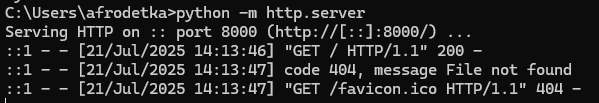

Также можно регнуть сервак внутри какого-либо директория, для этого прост надо перейти в него:

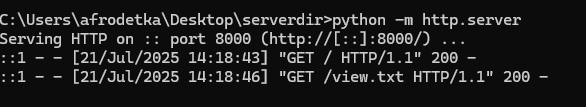

Также можно указать свой порт:

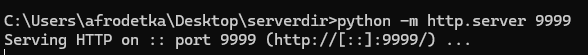

Чтоб узнать свой ip -> ipconfig в терминла + указываем его как на видосе, чтоб другой челик мог подключиться:

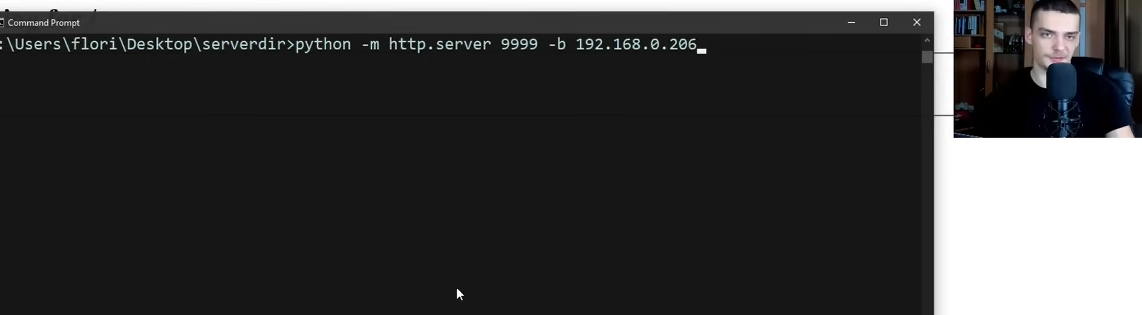

Простой пример как регнуть свой сервак:

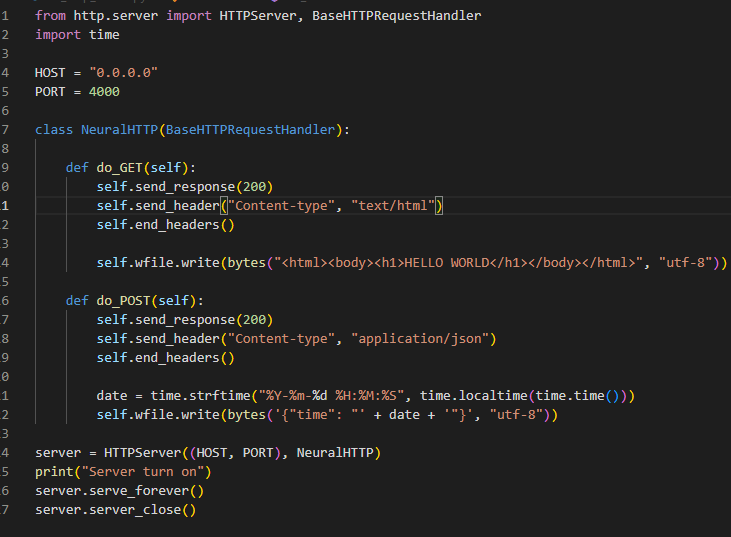

Как проверить запросы:

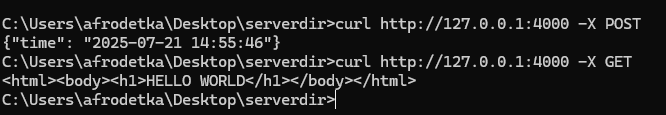

Как сделать эхо-страницу:

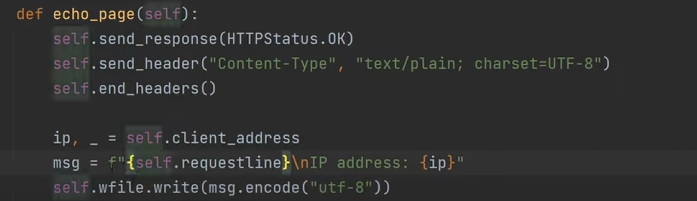

__Базовое устройство HTTP-сервера__

Основные компоненты:

HTTPServer - принимает соединения и управляет сервером

BaseHTTPRequestHandler - обрабатывает HTTP-запросы

SimpleHTTPRequestHandler - готовый обработчик для статических файлов

HTTPServer наследуется от socketserver.TCPServer и обрабатывает входящие соединения.

Основные методы:

serve_forever(poll_interval=0.5) - запускает бесконечный цикл обработки запросов

handle_request() - обрабатывает один запрос

server_close() - закрывает сервер

BaseHTTPRequestHandler

Этот класс обрабатывает HTTP-запросы. Основные атрибуты:

client_address - кортеж (host, port) клиента

command - метод запроса (GET, POST и т.д.)

path - путь запроса

headers - заголовки запроса

rfile - входной поток (для чтения тела запроса)

wfile - выходной поток (для записи ответа)

Основные методы для переопределения:

do_GET(), do_POST(), etc. - обработчики HTTP-методов

send_response(code, message=None) - отправка статуса ответа

send_header(name, value) - отправка заголовка

end_headers() - завершение заголовков

log_message(format, *args) - логирование запросов

In [ ]:
from http.server import BaseHTTPRequestHandler, HTTPServer
import json

class MyHandler(BaseHTTPRequestHandler):
    def do_GET(self):
        if self.path == '/':
            self.send_response(200)
            self.send_header('Content-type', 'text/html')
            self.end_headers()
            self.wfile.write(b"<h1>Welcome</h1><p>This is a test server.</p>")
        elif self.path == '/data':
            self.send_response(200)
            self.send_header('Content-type', 'application/json')
            self.end_headers()
            response = {"message": "Hello, world!", "status": "success"}
            self.wfile.write(json.dumps(response).encode())
        else:
            self.send_error(404, "Not Found")
    
    def do_POST(self):
        content_length = int(self.headers['Content-Length'])
        post_data = self.rfile.read(content_length)
        
        try:
            data = json.loads(post_data.decode())
            self.send_response(200)
            self.send_header('Content-type', 'application/json')
            self.end_headers()
            response = {"received": data, "status": "success"}
            self.wfile.write(json.dumps(response).encode())
        except json.JSONDecodeError:
            self.send_error(400, "Bad Request: Invalid JSON")

if __name__ == '__main__':
    server = HTTPServer(('localhost', 8000), MyHandler)
    print("Server started on http://localhost:8000")
    try:
        server.serve_forever()
    except KeyboardInterrupt:
        server.server_close()
        print("Server stopped")

Заголовки HTTP (HTTP headers) — это важная часть HTTP-протокола, которая передает дополнительную информацию между клиентом и сервером. В http.server модуле Python метод send_header() используется для отправки этих заголовков клиенту.

1) Content-Type (обязательные) - определяет тип передаваемых данных:

Популярные типы:

text/html - HTML-документ

text/plain - обычный текст

application/json - JSON-данные

image/png, image/jpeg - изображения

2)  Заголовки управления кэшированием

3) Заголовки безопасности

4) Заголовки для работы с куками

5) Специальные заголовки